# OBJECTIVE 4:
#### The Blame Game (Medium) Break down the root causes of delays across different airlines and figure out who is actually responsible.Are some carriers victims of bad weather and circumstances beyond their control, or are some just operationally terrible and what does accountability actually look like in the data?

Loaded dataset from: ../data/processed/merged_data.csv


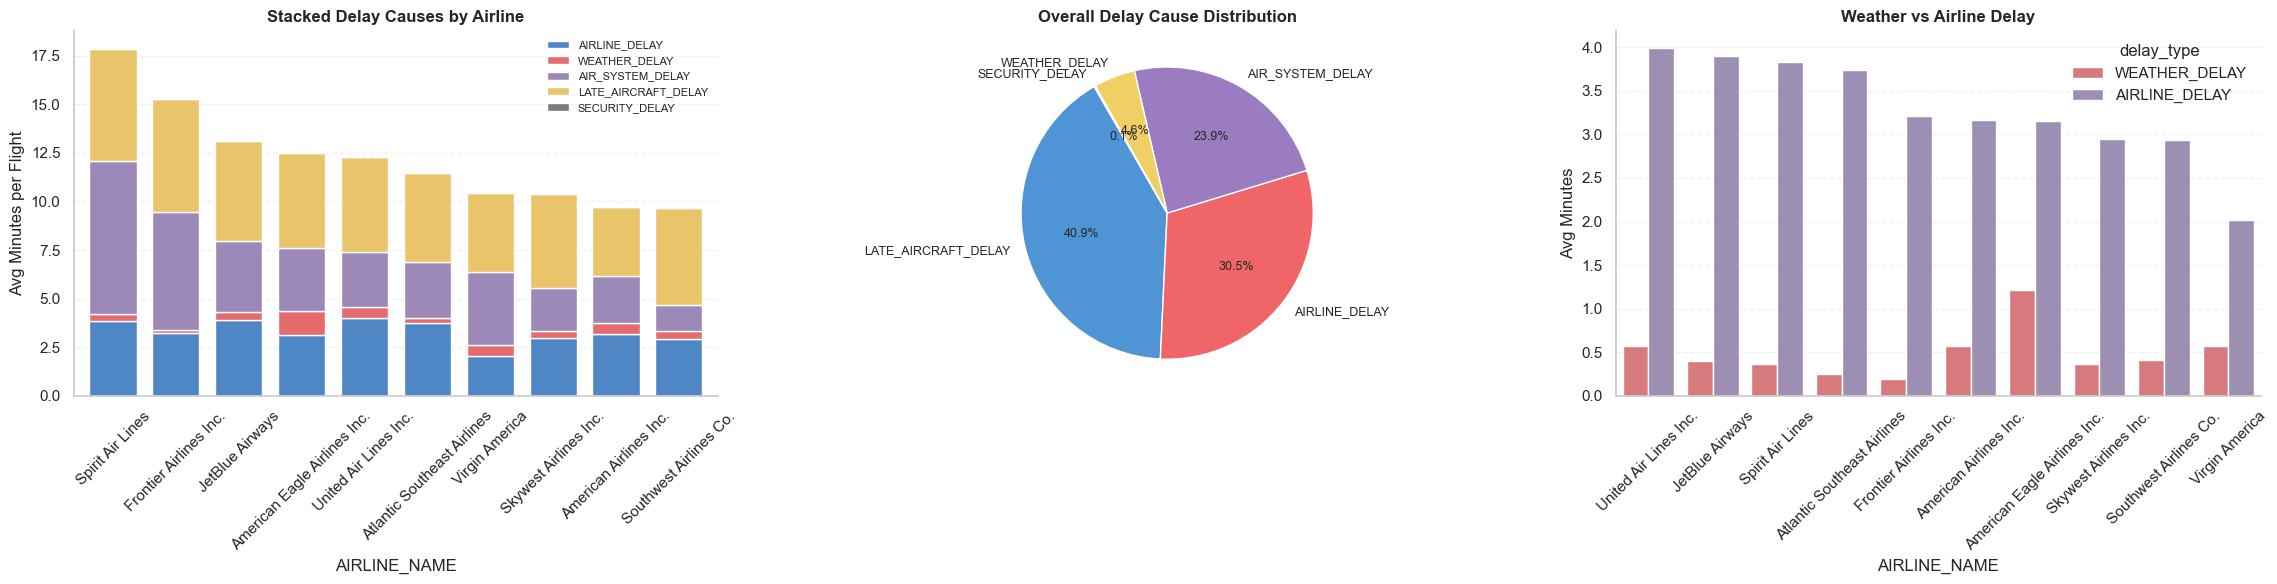


Blame Game Insights:
- Overall, the dominant causes come from AIRLINE_DELAY and LATE_AIRCRAFT_DELAY in this dataset.
- This suggests a large share of delays is operationally controllable rather than purely weather-driven.

Top 5 airlines with highest operational responsibility share:
               AIRLINE_NAME  controllable_share_pct  external_share_pct        accountability_label
     Hawaiian Airlines Inc.                   94.32                5.68 Operationally driven delays
     Southwest Airlines Co.                   81.84               18.16 Operationally driven delays
      Skywest Airlines Inc.                   75.05               24.95 Operationally driven delays
Atlantic Southeast Airlines                   72.59               27.41 Operationally driven delays
      United Air Lines Inc.                   72.25               27.75 Operationally driven delays

Top 5 airlines most impacted by external/system factors:
                AIRLINE_NAME  external_share_pct  contro

In [1]:
# ==========================================
# OBJECTIVE 4: The Blame Game (Medium)
# Root-cause breakdown of delays by airline
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')

# ------------------------------------------
# 1) Load dataset
# ------------------------------------------
possible_paths = [
    '../data/processed/merged_data.csv',
    'data/processed/merged_data.csv',
    'merged_data.csv'
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f'Loaded dataset from: {path}')
        break
    except FileNotFoundError:
        continue

if df is None:
    raise FileNotFoundError('merged_data.csv not found in expected locations.')

# ------------------------------------------
# 2) Clean and prepare cause columns
# ------------------------------------------
delay_cols = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'SECURITY_DELAY'
]

missing = [c for c in delay_cols + ['AIRLINE_NAME'] if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

for col in delay_cols + ['DIVERTED', 'CANCELLED']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Focus on operated flights for accountability analysis
if 'DIVERTED' in df.columns:
    df = df[df['DIVERTED'] == 0]
if 'CANCELLED' in df.columns:
    df = df[df['CANCELLED'] == 0]

# Per-flight average delay minutes by cause and airline
airline_cause = (
    df.groupby('AIRLINE_NAME', as_index=False)[delay_cols]
      .mean()
)
airline_cause['total_cause_delay'] = airline_cause[delay_cols].sum(axis=1)

# Use top airlines by total cause delay intensity (for readable charts)
top_n = 10
top_airlines = airline_cause.sort_values('total_cause_delay', ascending=False).head(top_n).copy()

# ------------------------------------------
# 3) Build 3-panel blame dashboard
# ------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(23, 6))

# A) Stacked delay causes by airline
stack_order = top_airlines.sort_values('total_cause_delay', ascending=False)['AIRLINE_NAME']
stack_df = top_airlines.set_index('AIRLINE_NAME').loc[stack_order, delay_cols]
stack_colors = ['#4F86C6', '#E56B6F', '#9C89B8', '#E9C46A', '#7B7B7B']
stack_df.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=stack_colors,
    width=0.75
)
axes[0].set_title('Stacked Delay Causes by Airline', weight='bold')
axes[0].set_xlabel('AIRLINE_NAME')
axes[0].set_ylabel('Avg Minutes per Flight')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper right', fontsize=8, frameon=False)

# B) Overall delay-cause distribution
overall_cause = df[delay_cols].sum().sort_values(ascending=False)
pie_colors = ['#4F95D6', '#F06567', '#9C7CC0', '#F0CF65', '#9E9E9E']
axes[1].pie(
    overall_cause.values,
    labels=overall_cause.index,
    autopct='%1.1f%%',
    startangle=120,
    colors=pie_colors,
    textprops={'fontsize': 9}
)
axes[1].set_title('Overall Delay Cause Distribution', weight='bold')

# C) Weather vs Airline delay comparison
compare = top_airlines.sort_values('AIRLINE_DELAY', ascending=False)[['AIRLINE_NAME', 'WEATHER_DELAY', 'AIRLINE_DELAY']]
compare_melt = compare.melt(
    id_vars='AIRLINE_NAME',
    value_vars=['WEATHER_DELAY', 'AIRLINE_DELAY'],
    var_name='delay_type',
    value_name='avg_minutes'
)
sns.barplot(
    data=compare_melt,
    x='AIRLINE_NAME',
    y='avg_minutes',
    hue='delay_type',
    palette={'WEATHER_DELAY': '#E56B6F', 'AIRLINE_DELAY': '#9C89B8'},
    ax=axes[2]
)
axes[2].set_title('Weather vs Airline Delay', weight='bold')
axes[2].set_xlabel('AIRLINE_NAME')
axes[2].set_ylabel('Avg Minutes')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title='delay_type', frameon=False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax is not axes[1]:
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

# ------------------------------------------
# 4) Accountability metrics and insights
# ------------------------------------------
# operationally controllable: airline operations + late aircraft rotations
# external/system: weather + air system + security
airline_accountability = airline_cause.copy()
airline_accountability['controllable_delay'] = (
    airline_accountability['AIRLINE_DELAY'] + airline_accountability['LATE_AIRCRAFT_DELAY']
)
airline_accountability['external_delay'] = (
    airline_accountability['WEATHER_DELAY'] + airline_accountability['AIR_SYSTEM_DELAY'] + airline_accountability['SECURITY_DELAY']
)
airline_accountability['total_delay'] = (
    airline_accountability['controllable_delay'] + airline_accountability['external_delay']
)

# Avoid divide-by-zero
airline_accountability['controllable_share_pct'] = np.where(
    airline_accountability['total_delay'] > 0,
    100 * airline_accountability['controllable_delay'] / airline_accountability['total_delay'],
    0
)
airline_accountability['external_share_pct'] = 100 - airline_accountability['controllable_share_pct']

# Labels for interpretation
airline_accountability['accountability_label'] = np.where(
    airline_accountability['controllable_share_pct'] >= 60,
    'Operationally driven delays',
    np.where(airline_accountability['external_share_pct'] >= 60, 'Mostly external/system pressure', 'Mixed responsibility')
)

worst_operational = airline_accountability.sort_values('controllable_share_pct', ascending=False).head(5)
worst_external = airline_accountability.sort_values('external_share_pct', ascending=False).head(5)

print()
print('Blame Game Insights:')
print('- Overall, the dominant causes come from AIRLINE_DELAY and LATE_AIRCRAFT_DELAY in this dataset.')
print('- This suggests a large share of delays is operationally controllable rather than purely weather-driven.')

print()
print('Top 5 airlines with highest operational responsibility share:')
print(worst_operational[['AIRLINE_NAME', 'controllable_share_pct', 'external_share_pct', 'accountability_label']].round(2).to_string(index=False))

print()
print('Top 5 airlines most impacted by external/system factors:')
print(worst_external[['AIRLINE_NAME', 'external_share_pct', 'controllable_share_pct', 'accountability_label']].round(2).to_string(index=False))

print()
print('Accountability Table (all airlines):')
print(
    airline_accountability[[
        'AIRLINE_NAME',
        'AIRLINE_DELAY',
        'LATE_AIRCRAFT_DELAY',
        'WEATHER_DELAY',
        'AIR_SYSTEM_DELAY',
        'SECURITY_DELAY',
        'controllable_share_pct',
        'external_share_pct',
        'accountability_label'
    ]]
    .sort_values('controllable_share_pct', ascending=False)
    .round(2)
    .to_string(index=False)
)

